In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

import tensorflow as tf

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense,Input,Dropout,GlobalAveragePooling2D,Flatten,Conv2D,BatchNormalization,Activation,MaxPooling2D
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.optimizers import Adam,SGD,RMSprop


2026-03-18 20:56:43.271911: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773867403.614246      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773867403.714413      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
print(tf.__version__)

2.18.0


In [3]:
print(os.listdir('../input/face-expression-recognition-dataset/images/'))

['validation', 'images', 'train']


In [4]:
folder_path = '../input/face-expression-recognition-dataset/images/'

print("Number of images per expression (class):")
tabel_header = f"{'Category':10} = {'Train':>7}, {'Validation':>7}"
print(len(tabel_header)*'-')
print(tabel_header)
print(len(tabel_header)*'-')
expressions = os.listdir(folder_path + "train/")
for expression in expressions:
    print(f"{expression:10} = ", end='')
    print(f"{len(os.listdir(folder_path + 'train/' + expression)):7}, {len(os.listdir(folder_path + 'validation/' + expression)):7}")

Number of images per expression (class):
--------------------------------
Category   =   Train, Validation
--------------------------------
surprise   =    3205,     797
fear       =    4103,    1018
angry      =    3993,     960
neutral    =    4982,    1216
sad        =    4938,    1139
disgust    =     436,     111
happy      =    7164,    1825


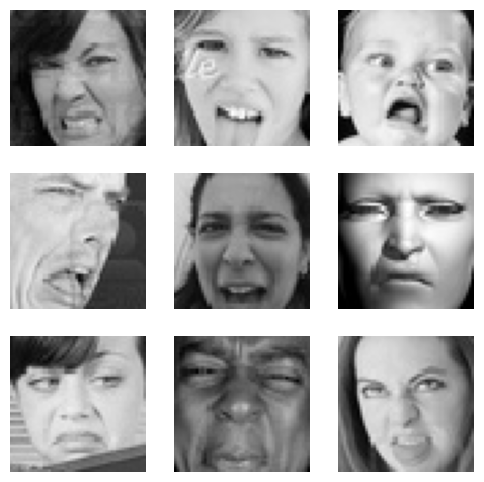

In [15]:
expression = 'disgust'
picture_size = 50

plt.figure(figsize= (6,6))
for i in range(1, 10, 1):
    plt.subplot(3,3,i)
    img = load_img(folder_path+"train/"+expression+"/"+
                   os.listdir(folder_path + "train/" + expression)[i+100],
                   target_size=(picture_size, picture_size))
    plt.imshow(img)
    plt.axis('off')
plt.show()

# New Data Loading

In [37]:
batch_size  = 128
picture_size = 224


# Training set (with validation split)
train_ds = tf.keras.utils.image_dataset_from_directory(
    folder_path+"train",
    validation_split=0.2,
    subset="training",
    seed=1,
    image_size=(picture_size, picture_size),
    batch_size=batch_size,
    color_mode="rgb",       # grayscale->3 channel done here
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    folder_path+"train",
    validation_split=0.2,
    subset="validation",
    seed=1,
    image_size=(picture_size, picture_size),
    batch_size=batch_size,
    color_mode="rgb",
    label_mode="categorical"
)

# Test set
test_ds = tf.keras.utils.image_dataset_from_directory(
    folder_path+"validation",
    image_size=(picture_size, picture_size),
    batch_size=batch_size,
    color_mode="rgb",
    label_mode="categorical",
    shuffle=False
)
class_names = list(train_ds.class_names)  # can't get class names after calling "prefetch"

Found 28821 files belonging to 7 classes.
Using 23057 files for training.
Found 28821 files belonging to 7 classes.
Using 5764 files for validation.
Found 7066 files belonging to 7 classes.


In [38]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)
# train_ds, val_ds, test_ds
print('Done')

Done


## Creating a custom salt and paper augmentation layer

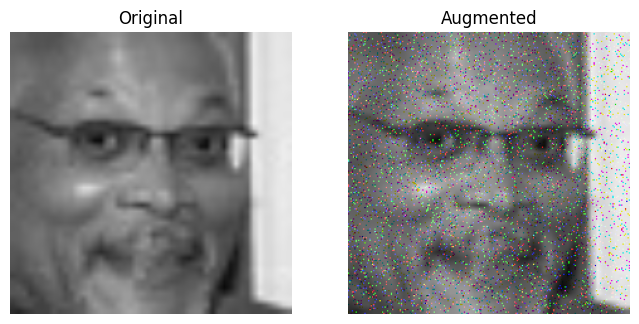

In [16]:
from tensorflow.keras import layers
class SaltAndPepperNoise(layers.Layer):
    def __init__(self, amount=0.05, salt_vs_pepper=0.5, **kwargs):
        super().__init__(**kwargs)
        self.amount = amount  # proportion of pixels to alter
        self.salt_vs_pepper = salt_vs_pepper  # ratio of salt vs pepper

    def call(self, inputs, training=None):
        if not training:
            return inputs

        # Generate random mask
        random_tensor = tf.random.uniform(tf.shape(inputs), 0, 1)

        # Salt mask (set to 1)
        salt_mask = random_tensor < (self.amount * self.salt_vs_pepper)

        # Pepper mask (set to 0)
        pepper_mask = (random_tensor >= (self.amount * self.salt_vs_pepper)) & \
                      (random_tensor < self.amount)

        # Apply noise
        outputs = tf.where(salt_mask, tf.ones_like(inputs), inputs)
        outputs = tf.where(pepper_mask, tf.zeros_like(inputs), outputs)

        return outputs

    def get_config(self):
        config = super().get_config()
        config.update({
            "amount": self.amount,
            "salt_vs_pepper": self.salt_vs_pepper
        })
        return config

rescale_layer = layers.Rescaling(1./255, name="rescale")

original_image = None
for images, labels in train_ds.take(1):
    original_image = images[0]  # shape (224,224,1)

# Add batch dimension (required by Keras layers)
image_batch = tf.expand_dims(original_image, 0)  # shape (1,224,224,1)

salt_and_paper_filter = SaltAndPepperNoise(amount=0.05)

rescaled_image = rescale_layer(image_batch, training=True)
augmented_image = salt_and_paper_filter(rescaled_image, training=True)

# Remove batch dimension and convert to numpy
augmented_image_np = augmented_image[0].numpy().squeeze()
original_image = rescaled_image[0].numpy().squeeze()

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(original_image, cmap='gray')
plt.title("Original")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(augmented_image_np, cmap='gray')
plt.title("Augmented")
plt.axis("off")

plt.show()

# Final Model (4)

## ==> Part 1

In [39]:
custom_head_config = {
    "num_dense_layers": 3,
    "layer_1_units": 256,
    "layer_1_dropout_rate": 0.5,
    "layer_2_units": 256,
    "layer_2_dropout_rate": 0.5,
    "layer_3_units": 128,
    "layer_3_dropout_rate": 0.3
}

In [40]:
from tensorflow.keras import layers, Model, Sequential

# 1. Define augmentation block
data_augmentation = Sequential([
    layers.RandomRotation(10/360),        # ~10 degrees
    layers.RandomTranslation(0.1, 0.1), # small shifts
    layers.RandomZoom(0.10),            # zoom
    layers.RandomContrast(0.1),         # contrast
    layers.RandomFlip("horizontal"),    # horizontal flip
], name="augmentation")

# Rescaling (applied always, train + val + test)
rescale = layers.Rescaling(1./255, name="rescale")

# salt_and_paper_filter = SaltAndPepperNoise(amount=0.05)

# 2. Load MobileNetV2 backbone (no top)
base_model = tf.keras.applications.MobileNetV2(
    weights=None,
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.load_weights("../input/mobilenet-v2-no-top/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5")
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))    # massive bug: shape=(224, 224, 1) 
x = rescale(inputs)                          
x = data_augmentation(x)    # massive bug: training=True , we are applying augmentation to val and test data
# x = salt_and_paper_filter(x, training=True)
# x = layers.Concatenate()([x, x, x])          # duplicate to 3 channels right before feeding to the base model
x = base_model(x, training=False)            #Feed to MobileNetV2
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(custom_head_config["layer_1_units"], activation="relu")(x) # start of additional layers other than single softmax layer
x = layers.BatchNormalization()(x)          
x = layers.Dropout(custom_head_config["layer_1_dropout_rate"])(x) #0.3
x = layers.Dense(custom_head_config["layer_2_units"], activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(custom_head_config["layer_2_dropout_rate"])(x) #0.3
x = layers.Dense(custom_head_config["layer_3_units"], activation="relu")(x)
x = layers.BatchNormalization()(x)         # last aditional layer added to the single output layer
x = layers.Dropout(custom_head_config["layer_3_dropout_rate"])(x)   #0.2              # stronger dropout to prevent overfitting than the (0.3) that was used with the single output layer
outputs = layers.Dense(7, activation="softmax")(x)

model = Model(inputs, outputs, name="mobilenetv2_finetune_phase1")
model.summary()



Model: "mobilenetv2_finetune_phase1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale (Rescaling)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,688,071 (10.25 MB)

 Trainable params: 428,807 (1.64 MB)

 Non-trainable params: 2,259,264 (8.62 MB)

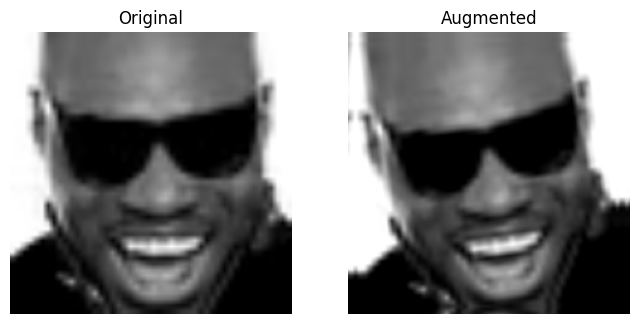

In [41]:
original_image = None
for images, labels in train_ds.take(1):
    original_image = images[0]  # shape (224,224,1)

# Add batch dimension (required by Keras layers)
image_batch = tf.expand_dims(original_image, 0)  # shape (1,224,224,1)

# Apply augmentation
augmented_image = data_augmentation(image_batch, training=True)

# Remove batch dimension and convert to numpy
augmented_image_np = augmented_image[0].numpy().squeeze()

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(original_image / 255, cmap='gray')
plt.title("Original")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(augmented_image_np / 255, cmap='gray')
plt.title("Augmented")
plt.axis("off")

plt.show()

In [42]:
from keras.optimizers import RMSprop,SGD,Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("/kaggle/working/model_phase1.h5", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
early_stopping = EarlyStopping(monitor='val_loss',min_delta=0, patience=3, verbose=1, restore_best_weights=True)
reduce_learningrate = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1, min_delta=0.0001, min_lr=0.000005)
callback_list = [early_stopping,checkpoint,reduce_learningrate]
epochs_count = 15   # 48

model.compile(loss='categorical_crossentropy',
              optimizer = Adam(learning_rate=1e-3),
              metrics=['accuracy'])

In [43]:
# train_ds, val_ds, test_ds
history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=epochs_count,
                    callbacks=callback_list)

Epoch 1/15


I0000 00:00:1773869449.171165     104 cuda_dnn.cc:529] Loaded cuDNN version 90300


181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.2477 - loss: 2.2864
Epoch 1: val_accuracy improved from -inf to 0.39087, saving model to /kaggle/working/model_phase1.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 61s 211ms/step - accuracy: 0.2480 - loss: 2.2851 - val_accuracy: 0.3909 - val_loss: 1.5376 - learning_rate: 0.0010
Epoch 2/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.3672 - loss: 1.7027
Epoch 2: val_accuracy improved from 0.39087 to 0.44934, saving model to /kaggle/working/model_phase1.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 39s 164ms/step - accuracy: 0.3672 - loss: 1.7025 - val_accuracy: 0.4493 - val_loss: 1.4381 - learning_rate: 0.0010
Epoch 3/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.4033 - loss: 1.5556
Epoch 3: val_accuracy improved from 0.44934 to 0.47016, saving model to /kaggle/working/model_phase1.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 39s 164ms/step - accuracy: 0.4034 - loss: 1.5555 - val_accuracy: 0.4702 - val_loss: 1.3877 - learning_rate: 0.0010
Epoch 

### Using ***DagsHub***

In [44]:
!pip install mlflow==2.9.2 dagshub==0.3.8 --quiet

# this may solve some comptability issues
# !pip uninstall -y protobuf 
# !pip install mlflow==2.9.2 dagshub==0.3.8 protobuf==3.20.3 pydantic==1.10.13 --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 69.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.5/185.5 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.1/148.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.0/38.0 MB 38.2 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 9.3 M

In [45]:
import mlflow
import dagshub

dagshub.init(repo_owner='michael-nabil', repo_name='face-emotion-recognition', mlflow=True)

# Set experiment name
mlflow.set_experiment("face_emotion_recognition")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=6af09bea-1bc5-4f9c-902d-ec20410e4961&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=33ce673f4a50e17423b12ae2aeee467ca418c33fd3f985b999077f6d1e0fb903




Repository initialized!

<Experiment: artifact_location='mlflow-artifacts:/bc671168ecb54f61b322b2fe9db31761', creation_time=1773706386192, experiment_id='0', last_update_time=1773706386192, lifecycle_stage='active', name='face_emotion_recognition', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [46]:
hyper_params = {
    "phase2_optimizer": 'Adam',
    "phase2_lr": 1e-5,
    "unfrozen_layers": 38,
    "phase2_epochs": 50,
    "batch_size": 128
}

## ==> Part 2

In [47]:
# 1. (Optional but recommended) Load the best weights from Phase 1
# This ensures you start Phase 2 from your absolute best checkpoint
model.load_weights("/kaggle/working/model_phase1.h5")

# 2. Unfreeze the base model
base_model.trainable = True

# 3. Freeze the early layers, unfreeze the late layers
# Let's see how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# We will fine-tune from layer 117 onwards (leaving the last 37 layers trainable)
fine_tune_at = len(base_model.layers) - hyper_params["unfrozen_layers"]

# Loop through the layers and freeze everything before 'fine_tune_at'
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Verify by printing how many layers are now trainable
trainable_count = sum([1 for w in model.trainable_weights])
print(f"Number of trainable weight tensors: {trainable_count}")

Number of layers in the base model:  154
Number of trainable weight tensors: 53


In [48]:
# 4. Update Callbacks for Phase 2
checkpoint_phase2 = ModelCheckpoint("/kaggle/working/model_phase2.h5", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
# We can give it a bit more patience now since fine-tuning is a slower process
early_stopping_phase2 = EarlyStopping(monitor='val_loss', min_delta=0, patience=5, verbose=1, restore_best_weights=True) 
reduce_lr_phase2 = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1, min_lr=1e-7)

callbacks_phase2 = [checkpoint_phase2, early_stopping_phase2, reduce_lr_phase2]

# 5. RECOMPILE the model
# CRITICAL: use a much lower learning rate (e.g., 1e-5) 
# If you use a high learning rate here, you will destroy the pre-trained weights.
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=hyper_params["phase2_lr"]),
              metrics=['accuracy'])

In [49]:
# 6. Train the model
epochs_phase2 = hyper_params["phase2_epochs"] # You can run this for longer because early stopping will catch it

print("Starting Phase 2: Fine-Tuning...")
history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_phase2,
    callbacks=callbacks_phase2
)

Starting Phase 2: Fine-Tuning...
Epoch 1/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.3628 - loss: 1.6613
Epoch 1: val_accuracy improved from -inf to 0.37266, saving model to /kaggle/working/model_phase2.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 67s 221ms/step - accuracy: 0.3630 - loss: 1.6608 - val_accuracy: 0.3727 - val_loss: 2.2948 - learning_rate: 1.0000e-05
Epoch 2/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.4392 - loss: 1.4566
Epoch 2: val_accuracy improved from 0.37266 to 0.43164, saving model to /kaggle/working/model_phase2.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 47s 208ms/step - accuracy: 0.4392 - loss: 1.4566 - val_accuracy: 0.4316 - val_loss: 1.8331 - learning_rate: 1.0000e-05
Epoch 3/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.4733 - loss: 1.3860
Epoch 3: val_accuracy improved from 0.43164 to 0.46860, saving model to /kaggle/working/model_phase2.h5
181/181 ━━━━━━━━━━━━━━━━━━━━ 47s 208ms/step - accuracy: 0.4733 - loss: 1.3859 - val_accuracy: 0.46

In [51]:
val_accuracy = history_phase2.history['val_accuracy'][-1]
train_accuracy = history_phase2.history['accuracy'][-1]

# ??
best_val_acc = max(history_phase2.history['val_accuracy'])  # because we saved the model with the best val_acc

print("model validation accuracy", val_accuracy)
print("best validation accuracy", best_val_acc)
print("training accuracy", train_accuracy)

model validation accuracy 0.6112074851989746
best validation accuracy 0.612248420715332
training accuracy 0.6706857085227966


In [52]:
np.argmax(history_phase2.history['val_accuracy'])

47

In [41]:
# assign the different places with this dictionary values
# use the new dataset

<class 'numpy.ndarray'>


Text(0.5, 1.0, 'Validation Confusion Matrix')

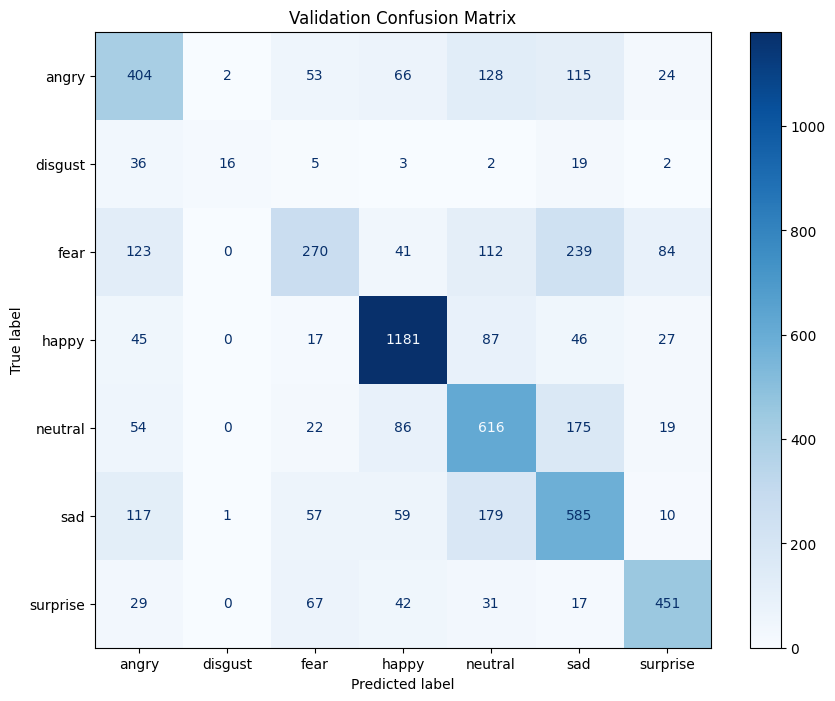

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_labels = []
all_preds = []
for images, labels in val_ds:
    all_labels.extend(np.argmax(labels.numpy(), axis=1))
    all_preds.extend(np.argmax(model.predict(images, verbose=0), axis=1))


cm = confusion_matrix(all_labels, all_preds)
print(type(cm))

# Plot it
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Validation Confusion Matrix')

# mlflow.log_figure(fig, "evaluation_plots/confusion_matrix.png")
# mlflow.log_dict(cm.tolist(), "evaluation/confusion_matrix_raw.json")

In [54]:
augmentation_params = {
    "aug_rotation_range": 10,
    "aug_translation": 0.1,
    "aug_zoom_range": 0.1,
    "aug_contrast_range": 0.1,
    "aug_horizontal_flip": True,
}

# 3. Define your dataset info
dataset_info = {
    "dataset_name": "Face_expression_recognition_dataset",
    "dataset_link": "https://www.kaggle.com/datasets/jonathanoheix/face-expression-recognition-dataset"
}

In [55]:
# Start your MLflow run
with mlflow.start_run(run_name="Exp2_Fixed_Augmentation_Leakage"):
    
    mlflow.log_params(hyper_params)
    mlflow.log_params(custom_head_config)

    mlflow.log_params(augmentation_params)
    mlflow.log_params(dataset_info)
    
    mlflow.log_metric("val_accuracy", val_accuracy)
    mlflow.log_metric("train_accuracy", train_accuracy)
    
    # 3. Evaluate on the Test Set & Log Test Metrics (use with final model)
    
    # test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    # mlflow.log_metric("test_accuracy", test_acc)

    # 4. Logging the Validation set Confusion Matrix
    mlflow.log_figure(fig, "evaluation_plots/confusion_matrix.png")
    mlflow.log_dict(cm.tolist(), "evaluation/confusion_matrix_raw.json")  # log the confusion matrix as a json file
    
    mlflow.log_artifact("/kaggle/working/model_phase2.h5", artifact_path="saved_models")

    mlflow.set_tag("experiment_type", "bug_fix")
    mlflow.set_tag(
        "mlflow.note.content", 
        "Fixed the augmentation data leak. Applying data augmentation to training set only."
    )

In [56]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

56/56 ━━━━━━━━━━━━━━━━━━━━ 17s 296ms/step - accuracy: 0.5541 - loss: 1.1565
Test Accuracy: 0.6149


## Model improvements ideas

### 1- use SGD with momentum=0.9
### 2- add a Layer or two layers in the FC classification head
### 3- change batch size
### 4- change learning rate
### 5- change in the augmentations
### 6- decreaset he number of unfreezed layers

## --------------------------------------------------------------------

## 1- change N of frozen layers, using SGD in pahse 2
## 2- add a layer in the classification head + change N of frozen layers + use SGD in phase2
## 3- Add penalty on the cost of underrepresented classes (disguast)
## 4- for each image in disuguast class, create 4 augmented versions for it during training